In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.signal import find_peaks
from scipy.stats import norm, gamma
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D
import time
import random

Loaded data from /content/drive/MyDrive/Applied_Mathematics/3.xlsx
Loaded time from /content/drive/MyDrive/Applied_Mathematics/time.xlsx
Detected time in milliseconds → converting to seconds.
Final time range (seconds): 0.0 to 307.474


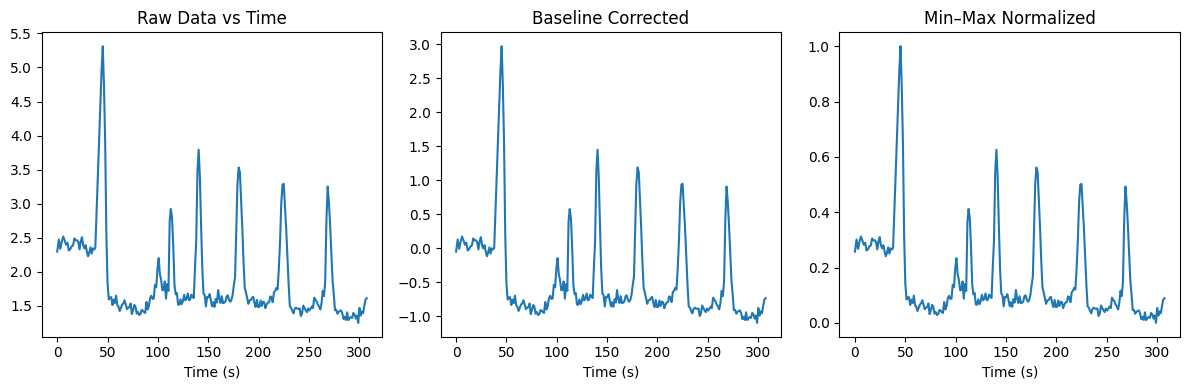

In [ ]:
# ==========================================
# 1. Data & Time Loading + Preprocessing
# ==========================================

try:
    data_path = '/content/drive/MyDrive/Applied_Mathematics/3.xlsx'
    time_path = '/content/drive/MyDrive/Applied_Mathematics/time.xlsx'

    # ---- Load experimental DATA ----
    df = pd.read_excel(data_path, header=None)
    exp_raw = df.iloc[:,3].astype(float).values   # 4th column

    # ---- Load TIME from separate file ----
    tf = pd.read_excel(time_path, header=None, skiprows=1)
    time_raw = tf.iloc[:, 0].astype(float).values

    print(f"Loaded data from {data_path}")
    print(f"Loaded time from {time_path}")

    # ---- Align lengths ----
    n = min(len(exp_raw), len(time_raw))
    exp_raw = exp_raw[:n]
    time_raw = time_raw[:n]

    # ---- Remove NaNs & infinities ----
    mask = np.isfinite(exp_raw) & np.isfinite(time_raw)
    exp_data = exp_raw[mask]
    time_exp = time_raw[mask]

    # ---- Sort by time ----
    sort_idx = np.argsort(time_exp)
    time_exp = time_exp[sort_idx]
    exp_data = exp_data[sort_idx]

    # ---- CONVERT TIME: milliseconds → seconds ----
    if np.nanmax(time_exp) > 1000:   # clearly in ms
        print("Detected time in milliseconds → converting to seconds.")
        time_exp = time_exp / 1000.0

    # ---- Shift so time starts at 0 s ----
    time_exp = time_exp - time_exp[0]

    print("Final time range (seconds):", float(time_exp[0]), "to", float(time_exp[-1]))

except Exception as e:
    print("Warning: issue loading data/time:", e)
    # fallback synthetic time (seconds)
    time_exp = np.arange(0, len(exp_data) * 0.1, 0.1)

# ---- Baseline correction (seconds-independent) ----
baseline = np.median(exp_data[:int(0.2 * len(exp_data))])
exp_corrected = exp_data - baseline

# ---- Normalize to [0, 1] ----
scaler = MinMaxScaler()
exp_norm = scaler.fit_transform(exp_corrected.reshape(-1, 1)).flatten()

# ---- Visualize Preprocessing (SECONDS) ----
plt.figure(figsize=(12, 4))
plt.subplot(1,3,1)
plt.plot(time_exp, exp_data)
plt.xlabel("Time (s)")
plt.title("Raw Data vs Time")

plt.subplot(1,3,2)
plt.plot(time_exp, exp_corrected)
plt.xlabel("Time (s)")
plt.title("Baseline Corrected")

plt.subplot(1,3,3)
plt.plot(time_exp, exp_norm)
plt.xlabel("Time (s)")
plt.title("Min–Max Normalized")

plt.tight_layout()
plt.show()

# ---- GLOBAL TIME STEP IN SECONDS FOR SIMULATION & FFT ----
dt_exp = np.median(np.diff(time_exp))     # seconds
DT_SIM = dt_exp                            # enforce simulation dt in seconds

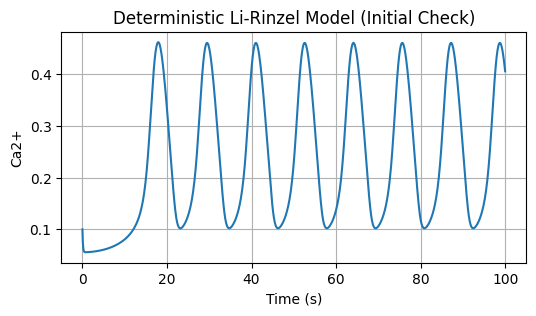

In [ ]:
# ==========================================
# 2. Li-Rinzel Model Simulation
# ==========================================
def simulate_lir_rinzel(k3=0.1, v2=0.11, d5=0.08234, a2=0.2, dt=0.1, t_max=100):
    IP3 = 0.5
    v1 = 6.0
    v3 = 0.9
    c0 = 2.0
    c1 = 0.185
    d1 = 0.13
    d2 = 1.049
    d3 = 0.9434

    time = np.arange(0, t_max + dt, dt)
    n_points = len(time)
    Ca = np.zeros(n_points)
    h = np.zeros(n_points)

    # Initial conditions
    Ca[0] = 0.1
    h[0] = 0.1

    # Pre-calc constants
    p = IP3 / (IP3 + d1)
    Q2 = d2 * (IP3 + d1) / (IP3 + d3)

    for t in range(1, n_points):
        Ca_prev = Ca[t-1]
        h_prev = h[t-1]

        CaER = (c0 - Ca_prev) / c1
        n = Ca_prev / (Ca_prev + d5)

        # Dynamics for h
        hinf = Q2 / (Q2 + Ca_prev)
        tauh = 1 / (a2 * (Q2 + Ca_prev))
        alphah = hinf / tauh
        betah = (1 - hinf) / tauh

        # Derivatives
        dh = alphah * (1 - h_prev) - betah * h_prev

        # Flux terms
        J_chan = c1 * v1 * (p**3) * (n**3) * (h_prev**3) * (CaER - Ca_prev)
        J_leak = c1 * v2 * (CaER - Ca_prev)
        J_pump = v3 * (Ca_prev**2) / (Ca_prev**2 + k3**2)

        dCa = J_chan + J_leak - J_pump

        # Euler update
        Ca[t] = Ca_prev + dt * dCa
        h[t] = h_prev + dt * dh

    return time, Ca, h

# Sanity Check Plot
t_test, Ca_test, _ = simulate_lir_rinzel(0.1, 0.11)
plt.figure(figsize=(6, 3))
plt.plot(t_test, Ca_test)
plt.title("Deterministic Li-Rinzel Model (Initial Check)")
plt.xlabel('Time (s)')
plt.ylabel('Ca2+')
plt.grid(True)
plt.show()

In [ ]:
# ==========================================
# 3. Parametric KL Divergence (MLE Based)
# ==========================================

def calculate_parametric_kl(p_data, q_data):
    """
    1. Fits a Normal (Gaussian) distribution to both datasets using MLE (norm.fit).
    2. Calculates KL Divergence between the two theoretical Gaussians.
    """
    # MLE Fitting: Get Mean (mu) and Std Dev (sigma)
    mu_p, std_p = norm.fit(p_data)
    mu_q, std_q = norm.fit(q_data)

    # Avoid division by zero
    std_p = max(std_p, 1e-6)
    std_q = max(std_q, 1e-6)

    # Analytical KL Divergence for two Gaussian distributions
    # Formula: log(s2/s1) + (s1^2 + (m1-m2)^2)/(2*s2^2) - 1/2
    kl_val = (np.log(std_q / std_p) +
              ((std_p**2 + (mu_p - mu_q)**2) / (2 * std_q**2)) -
              0.5)

    # Generate distribution lines for plotting (Continuity)
    x_grid = np.linspace(min(min(p_data), min(q_data)),
                         max(max(p_data), max(q_data)), 200)

    p_pdf = norm.pdf(x_grid, mu_p, std_p)
    q_pdf = norm.pdf(x_grid, mu_q, std_q)

    return kl_val, x_grid, p_pdf, q_pdf

def calculate_parametric_kl_gamma(p_data, q_data):
    """
    Fits Gamma distributions via MLE and computes KL using numerical integration.
    Robust version: shifts data to positive, fixes loc=0, clips PDFs, renormalizes,
    and returns np.nan if the result is not numerically reliable.
    """
    p_data = np.asarray(p_data, dtype=float)
    q_data = np.asarray(q_data, dtype=float)

    # Remove NaNs / infs
    p_data = p_data[np.isfinite(p_data)]
    q_data = q_data[np.isfinite(q_data)]
    if p_data.size < 3 or q_data.size < 3:
        return np.nan, None, None, None

    # Shift data to be strictly positive
    shift = min(p_data.min(), q_data.min())
    p_pos = p_data - shift + 1e-6
    q_pos = q_data - shift + 1e-6

    # Fit Gamma with loc fixed to 0 (more stable)
    with np.errstate(all='ignore'):
        try:
            shape_p, loc_p, scale_p = gamma.fit(p_pos, floc=0)
            shape_q, loc_q, scale_q = gamma.fit(q_pos, floc=0)
        except Exception:
            return np.nan, None, None, None

    # If any parameter is non-finite, give up
    if not np.all(np.isfinite([shape_p, scale_p, shape_q, scale_q])) or \
       scale_p <= 0 or scale_q <= 0:
        return np.nan, None, None, None

    # Use a robust x-range (avoid crazy tails)
    low = min(np.percentile(p_pos, 0.5), np.percentile(q_pos, 0.5))
    high = max(np.percentile(p_pos, 99.5), np.percentile(q_pos, 99.5))
    if high <= low:
        high = low + 1.0
    x_grid = np.linspace(low, high, 400)

    # PDFs
    with np.errstate(over='ignore', under='ignore', divide='ignore', invalid='ignore'):
        p_pdf = gamma.pdf(x_grid, shape_p, loc=0, scale=scale_p)
        q_pdf = gamma.pdf(x_grid, shape_q, loc=0, scale=scale_q)

    # Clip and renormalize
    eps = 1e-12
    p_pdf = np.clip(p_pdf, eps, 1e6)
    q_pdf = np.clip(q_pdf, eps, 1e6)

    # Normalize to integrate to ~1
    p_area = np.trapezoid(p_pdf, x_grid)
    q_area = np.trapezoid(q_pdf, x_grid)
    if not np.isfinite(p_area) or p_area <= 0 or not np.isfinite(q_area) or q_area <= 0:
        return np.nan, x_grid, p_pdf, q_pdf

    p_pdf /= p_area
    q_pdf /= q_area

    # KL integrand
    with np.errstate(divide='ignore', invalid='ignore'):
        integrand = p_pdf * np.log(p_pdf / q_pdf)

    integrand = np.nan_to_num(integrand, nan=0.0, posinf=0.0, neginf=0.0)
    kl_val = float(np.trapezoid(integrand, x_grid))

    if not np.isfinite(kl_val):
        kl_val = np.nan

    return kl_val, x_grid, p_pdf, q_pdf

In [ ]:
# ==========================================
# 4. Monte Carlo Search (Random, No Grid)
# ==========================================

random.seed(44)
np.random.seed(44)
# Total simulations
N_Simulations = 900

# Randomly sample ALL parameters (Pure Monte Carlo)
k3_samples = np.random.uniform(0.05, 0.15, N_Simulations)
v2_samples = np.random.uniform(0.05, 0.15, N_Simulations)
d5_samples = np.random.uniform(0.05, 0.15, N_Simulations)
a2_samples = np.random.uniform(0.1, 0.3, N_Simulations)

# Lists to store results (Lists are better for Monte Carlo than 2D arrays)
results_k3 = []
results_v2 = []
results_rmse = []
results_score_raw = []   # raw objective = freq_diff + KL  (for optimization)
results_score = []       # will hold normalized objective for plotting
results_kl = []          # parametric KL values (raw)
results_freqdiff = []    # frequency difference
animation_frames = []

best_score = float('inf')
best_params = {}
best_sim_trace = None
best_metrics = {}

print(f"Starting Pure Monte Carlo Search: {N_Simulations} random iterations...")

for i in range(N_Simulations):

    # Parameters from random arrays
    k3_val = k3_samples[i]
    v2_val = v2_samples[i]
    d5_val = d5_samples[i]
    a2_val = a2_samples[i]

    # also get time for interpolation
    t_sim_mc, sim_Ca, _ = simulate_lir_rinzel(k3_val, v2_val, d5_val, a2_val, t_max=time_exp[-1])

    # Preprocess WITH EXPLICIT INTERPOLATION onto experimental time grid
    if np.max(sim_Ca) - np.min(sim_Ca) == 0:
        sim_norm_raw = np.zeros_like(sim_Ca)
    else:
        sim_norm_raw = scaler.transform(sim_Ca.reshape(-1, 1)).flatten()

    # Interpolate simulated data to experimental time (Requirement 1)
    sim_interp_mc = np.interp(time_exp, t_sim_mc, sim_norm_raw)

    sim_trunc = sim_interp_mc[:len(exp_norm)]
    if len(sim_trunc) == 0:
        continue

    sim_norm = sim_trunc  # use interpolated, normalized signal

    # Metrics
    peaks_exp, _ = find_peaks(exp_norm, height=0.2, distance=10)
    freq_exp = 1 / np.mean(np.diff(time_exp[peaks_exp])) if len(peaks_exp) > 1 else 0
    peaks_sim, _ = find_peaks(sim_norm, height=0.2, distance=10)
    freq_sim = 1 / np.mean(np.diff(time_exp[peaks_sim])) if len(peaks_sim) > 1 else 0
    freq_diff = abs(freq_exp - freq_sim)

    # PARAMETRIC KL (Gaussian)
    kl_val, _, _, _ = calculate_parametric_kl(exp_norm, sim_norm)
    rmse_val = np.sqrt(np.mean((exp_norm - sim_norm) ** 2))

    # Store for plotting & post-processing
    results_k3.append(k3_val)
    results_v2.append(v2_val)
    results_rmse.append(rmse_val)
    results_kl.append(kl_val)
    results_freqdiff.append(freq_diff)

    current_score = freq_diff + kl_val        # objective used for optimization
    results_score_raw.append(current_score)   # store raw objective

    # Store for video (every 1st frame as you already do)
    if i % 1 == 0:
         animation_frames.append({
            'k3': k3_val, 'v2': v2_val, 'rmse': rmse_val,
            'score': current_score, 'sim_data': sim_norm, 'type': 'trial'
        })

    if current_score < best_score:
        best_score = current_score
        best_params = {'k3': k3_val, 'v2': v2_val, 'd5': d5_val, 'a2': a2_val}
        best_sim_trace = sim_norm
        best_metrics = {'KL': kl_val, 'RMSE': rmse_val, 'FreqDiff': freq_diff}

print(f"Best Parameters: {best_params}")
print(f"Best Metrics: {best_metrics}")

# Append best frame for video
if best_sim_trace is not None:
    animation_frames.append({
        'k3': best_params['k3'], 'v2': best_params['v2'],
        'rmse': best_metrics['RMSE'], 'score': best_score,
        'sim_data': best_sim_trace, 'type': 'best'
    })

Starting Pure Monte Carlo Search: 900 random iterations...
Best Parameters: {'k3': np.float64(0.05578453291033456), 'v2': np.float64(0.054995217677950486), 'd5': np.float64(0.0637860583106155), 'a2': np.float64(0.1419958699754235)}
Best Metrics: {'KL': np.float64(3.8468497539142508), 'RMSE': np.float64(0.23302378258796014), 'FreqDiff': np.float64(0.004669447116820762)}


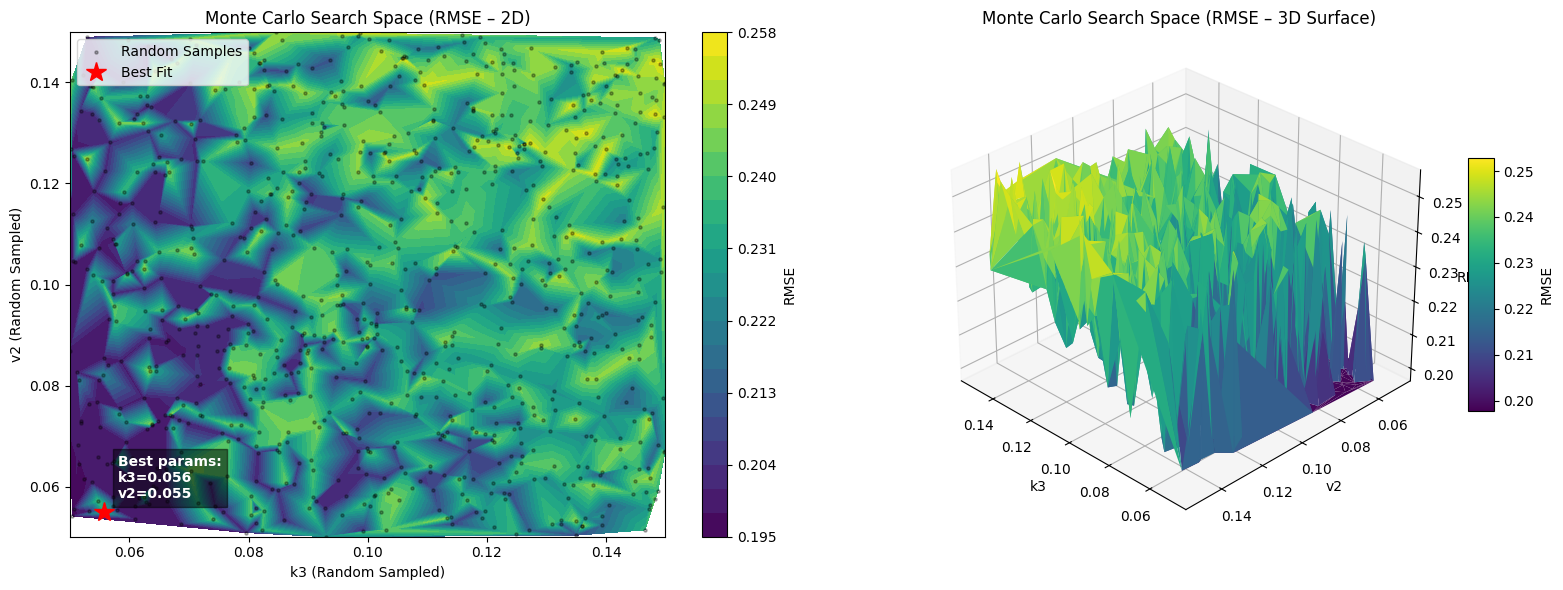

In [ ]:
# ------------------------------------------
# A. Monte Carlo "Heatmap" (Triangulated Contour) – RMSE
# ------------------------------------------
fig = plt.figure(figsize=(16, 6))

# ---------- LEFT: 2D RMSE heatmap ----------
ax1 = fig.add_subplot(1, 2, 1)

cont = ax1.tricontourf(results_k3, results_v2, results_rmse, levels=20, cmap='viridis')
cbar1 = fig.colorbar(cont, ax=ax1)
cbar1.set_label('RMSE')

ax1.scatter(results_k3, results_v2, c='black', s=5, alpha=0.3, label='Random Samples')
ax1.plot(best_params['k3'], best_params['v2'], 'r*', markersize=15, label='Best Fit')

ax1.annotate(
    f"Best params:\nk3={best_params['k3']:.3f}\nv2={best_params['v2']:.3f}",
    (best_params['k3'], best_params['v2']),
    color='white', fontweight='bold',
    xytext=(10, 10), textcoords='offset points',
    bbox=dict(facecolor='black', alpha=0.5)
)

ax1.set_xlabel('k3 (Random Sampled)')
ax1.set_ylabel('v2 (Random Sampled)')
ax1.set_title('Monte Carlo Search Space (RMSE – 2D)')
ax1.legend()

# ---------- RIGHT: 3D RMSE surface ----------
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

surf = ax2.plot_trisurf(results_k3, results_v2, results_rmse, cmap='viridis', linewidth=0.2, antialiased=True)
cbar2 = fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=10)
cbar2.set_label('RMSE')

ax2.set_xlabel('k3')
ax2.set_ylabel('v2')
ax2.set_zlabel('RMSE')
ax2.set_title('Monte Carlo Search Space (RMSE – 3D Surface)')

# Optional: adjust viewing angle
ax2.view_init(elev=30, azim=135)

plt.tight_layout()
plt.show()

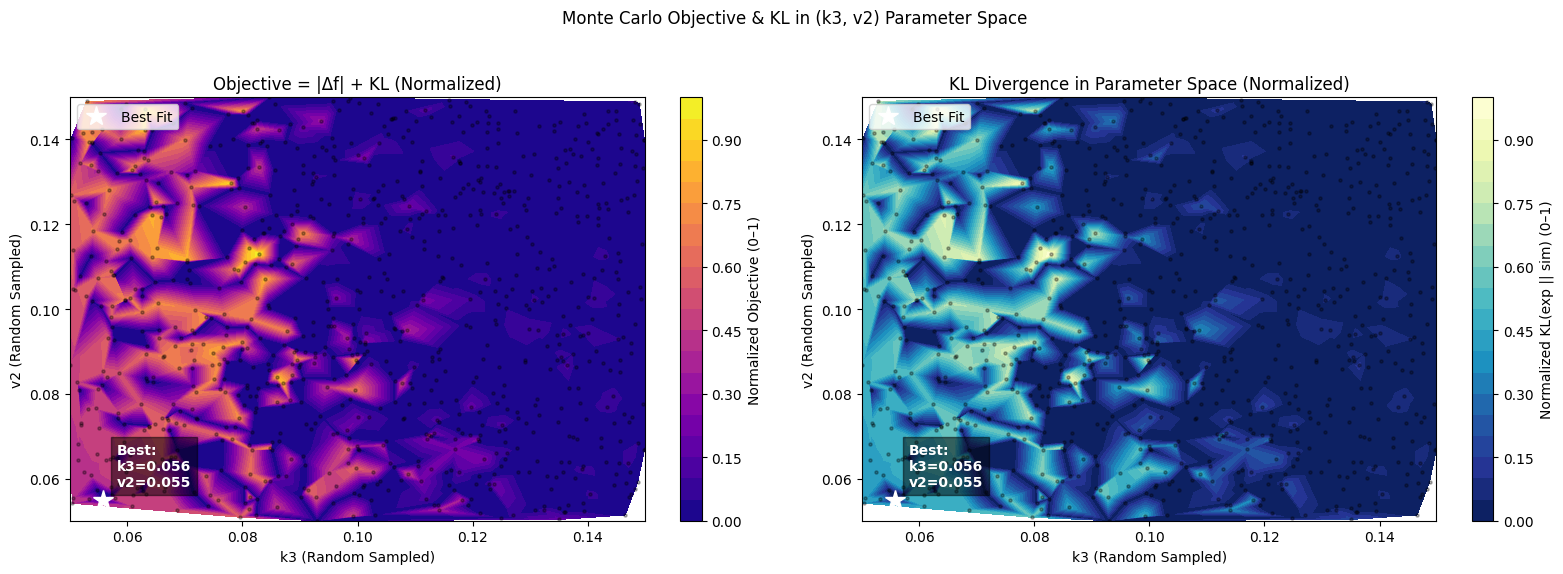

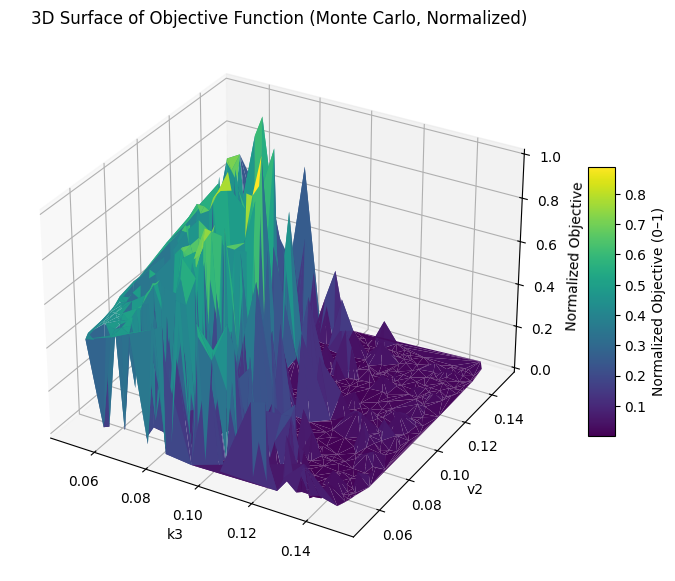

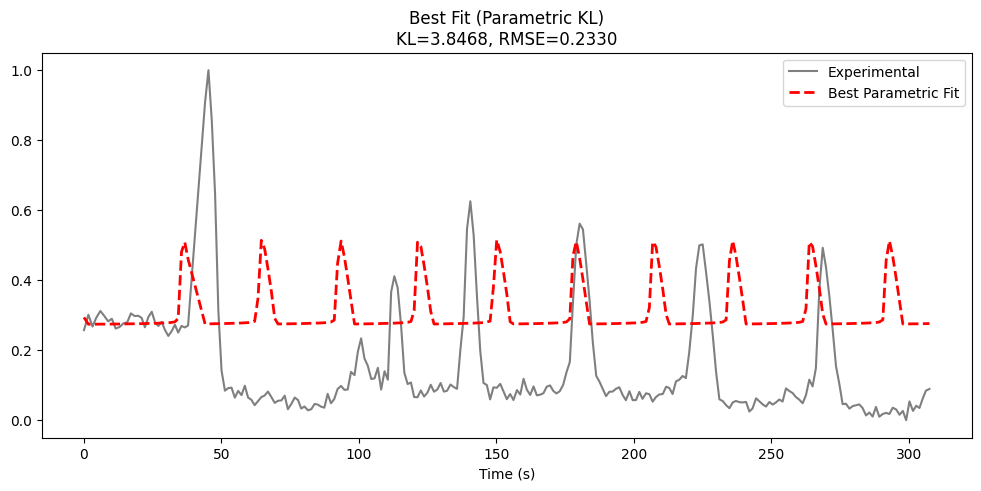

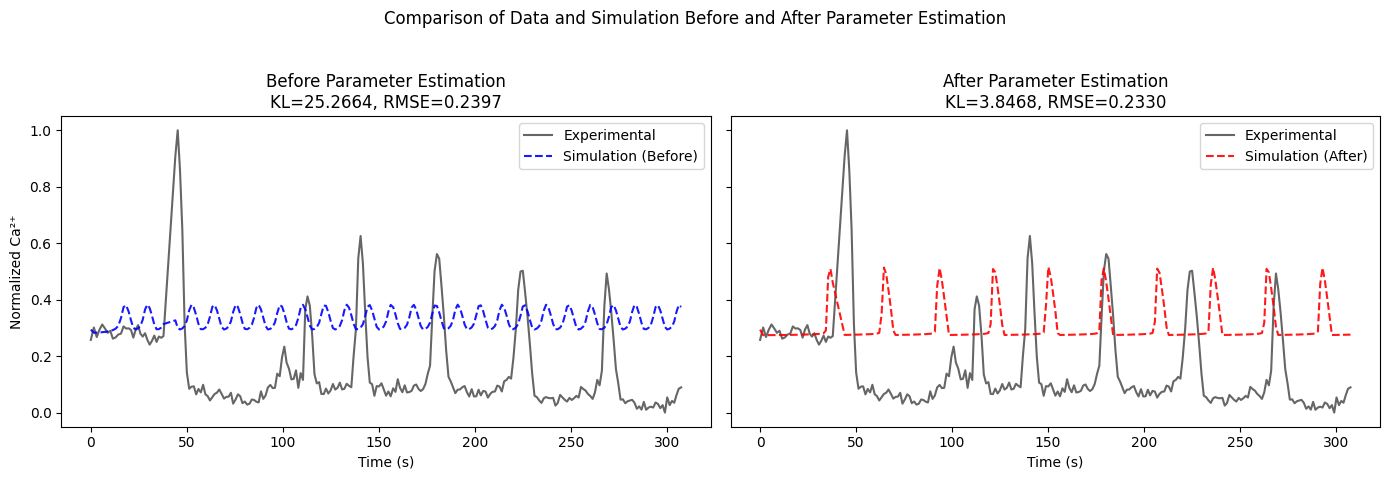

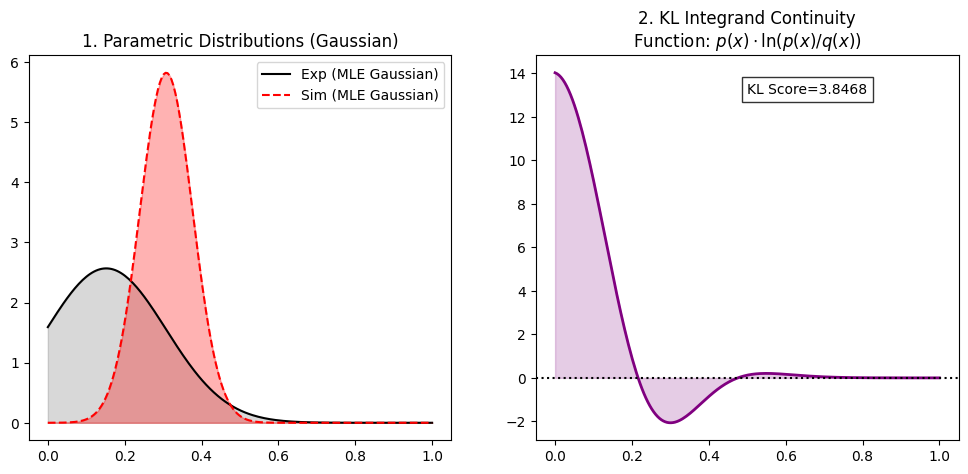

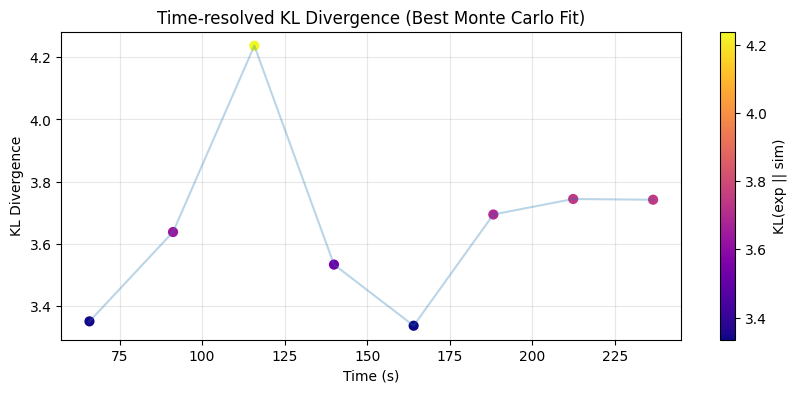

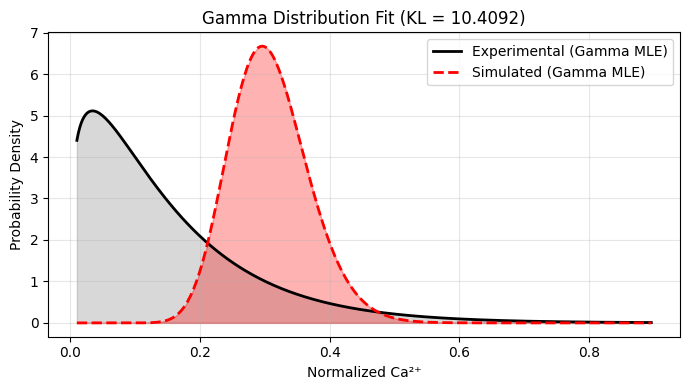

In [ ]:
# ==========================================
# 5. Visualization
# ==========================================

# ---- Normalize objective and KL ONLY FOR PLOTS (0–1 scale) ----
results_score_raw_arr = np.array(results_score_raw, dtype=float)
results_kl_arr        = np.array(results_kl,        dtype=float)

def _normalize(arr):
    if arr.size == 0:
        return arr
    mn = np.min(arr)
    mx = np.max(arr)
    if mx - mn < 1e-12:
        return np.zeros_like(arr)
    return (arr - mn) / (mx - mn)

score_plot = _normalize(results_score_raw_arr)
kl_plot    = _normalize(results_kl_arr)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Objective
cs0 = axes[0].tricontourf(results_k3, results_v2, score_plot, levels=20, cmap='plasma')
fig.colorbar(cs0, ax=axes[0], label='Normalized Objective (0–1)')
axes[0].scatter(results_k3, results_v2, c='black', s=5, alpha=0.3)
axes[0].plot(best_params['k3'], best_params['v2'], 'w*', markersize=15, label='Best Fit')
axes[0].annotate(f"Best:\nk3={best_params['k3']:.3f}\nv2={best_params['v2']:.3f}",
                 (best_params['k3'], best_params['v2']), color='white', fontweight='bold',
                 xytext=(10, 10), textcoords='offset points',
                 bbox=dict(facecolor='black', alpha=0.5))
axes[0].set_xlabel('k3 (Random Sampled)')
axes[0].set_ylabel('v2 (Random Sampled)')
axes[0].set_title('Objective = |Δf| + KL (Normalized)')
axes[0].legend()

# Right: KL
cs1 = axes[1].tricontourf(results_k3, results_v2, kl_plot, levels=20, cmap='YlGnBu_r')
fig.colorbar(cs1, ax=axes[1], label='Normalized KL(exp || sim) (0–1)')
axes[1].scatter(results_k3, results_v2, c='black', s=5, alpha=0.3)
axes[1].plot(best_params['k3'], best_params['v2'], 'w*', markersize=15, label='Best Fit')
axes[1].annotate(f"Best:\nk3={best_params['k3']:.3f}\nv2={best_params['v2']:.3f}",
                 (best_params['k3'], best_params['v2']), color='white', fontweight='bold',
                 xytext=(10, 10), textcoords='offset points',
                 bbox=dict(facecolor='black', alpha=0.5))
axes[1].set_xlabel('k3 (Random Sampled)')
axes[1].set_ylabel('v2 (Random Sampled)')
axes[1].set_title('KL Divergence in Parameter Space (Normalized)')
axes[1].legend()

plt.suptitle('Monte Carlo Objective & KL in (k3, v2) Parameter Space')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ------------------------------------------
# A.3 3D Surface plot of Objective (Requirement 3)
# ------------------------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_trisurf(results_k3, results_v2, score_plot, cmap='viridis')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Normalized Objective (0–1)')
ax.set_xlabel('k3')
ax.set_ylabel('v2')
ax.set_zlabel('Normalized Objective')
ax.set_title('3D Surface of Objective Function (Monte Carlo, Normalized)')
plt.show()

# ------------------------------------------
# B. Best Fit Time Series (after optimization)
# ------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(time_exp, exp_norm, 'k-', alpha=0.5, label='Experimental')
if best_sim_trace is not None:
    plt.plot(time_exp, best_sim_trace, 'r--', linewidth=2, label='Best Parametric Fit')
plt.title(f"Best Fit (Parametric KL)\nKL={best_metrics['KL']:.4f}, RMSE={best_metrics['RMSE']:.4f}")
plt.xlabel('Time (s)')
plt.legend()
plt.show()

# ------------------------------------------
# B.1 Before vs After parameter estimation (Requirement 5)
# ------------------------------------------
# Baseline "before optimization" using default Li-Rinzel parameters
t_base, sim_base_raw, _ = simulate_lir_rinzel(t_max=time_exp[-1])
if np.max(sim_base_raw) - np.min(sim_base_raw) < 1e-6:
    sim_base_norm_raw = np.zeros_like(sim_base_raw)
else:
    sim_base_norm_raw = scaler.transform(sim_base_raw.reshape(-1, 1)).flatten()
sim_base_interp = np.interp(time_exp, t_base, sim_base_norm_raw)
sim_base = sim_base_interp[:len(exp_norm)]

kl_before, _, _, _ = calculate_parametric_kl(exp_norm, sim_base)
rmse_before = np.sqrt(np.mean((exp_norm - sim_base) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Before
axes[0].plot(time_exp, exp_norm, 'k-', alpha=0.6, label='Experimental')
axes[0].plot(time_exp, sim_base, 'b--', alpha=0.9, label='Simulation (Before)')
axes[0].set_title(f"Before Parameter Estimation\nKL={kl_before:.4f}, RMSE={rmse_before:.4f}")
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Normalized Ca²⁺')
axes[0].legend()

# After
axes[1].plot(time_exp, exp_norm, 'k-', alpha=0.6, label='Experimental')
if best_sim_trace is not None:
    axes[1].plot(time_exp, best_sim_trace, 'r--', alpha=0.9, label='Simulation (After)')
axes[1].set_title(f"After Parameter Estimation\nKL={best_metrics['KL']:.4f}, RMSE={best_metrics['RMSE']:.4f}")
axes[1].set_xlabel('Time (s)')
axes[1].legend()

plt.suptitle("Comparison of Data and Simulation Before and After Parameter Estimation")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ------------------------------------------
# C. Parametric KL Continuity (Integrand Plot, Gaussian)
# ------------------------------------------
_, x_grid, p_pdf, q_pdf = calculate_parametric_kl(exp_norm, best_sim_trace)
eps = 1e-12
integrand = (p_pdf + eps) * np.log((p_pdf + eps) / (q_pdf + eps))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# PDFs
ax1.plot(x_grid, p_pdf, 'k-', label='Exp (MLE Gaussian)')
ax1.plot(x_grid, q_pdf, 'r--', label='Sim (MLE Gaussian)')
ax1.fill_between(x_grid, p_pdf, alpha=0.3, color='gray')
ax1.fill_between(x_grid, q_pdf, alpha=0.3, color='red')
ax1.set_title("1. Parametric Distributions (Gaussian)")
ax1.legend()

# Integrand
ax2.plot(x_grid, integrand, 'purple', linewidth=2)
ax2.fill_between(x_grid, integrand, color='purple', alpha=0.2)
ax2.axhline(0, color='k', linestyle=':')
ax2.set_title("2. KL Integrand Continuity\nFunction: " + r"$p(x) \cdot \ln(p(x)/q(x))$")
ax2.text(0.5, 0.9, f"KL Score={best_metrics['KL']:.4f}", transform=ax2.transAxes,
         bbox=dict(facecolor='white', alpha=0.8))
plt.show()

# ------------------------------------------
# C.1 Time-resolved KL divergence (Requirement 1 & 2: KL with time + color)
# ------------------------------------------
def compute_time_resolved_kl(exp_signal, sim_signal, t, window_size=100, step_size=20):
    exp_signal = np.asarray(exp_signal)
    sim_signal = np.asarray(sim_signal)
    t = np.asarray(t)

    n = min(len(exp_signal), len(sim_signal), len(t))
    exp_signal = exp_signal[:n]
    sim_signal = sim_signal[:n]
    t = t[:n]

    kl_vals = []
    t_centers = []

    if n < window_size:
        return np.array([]), np.array([])

    for start in range(0, n - window_size + 1, step_size):
        e_seg = exp_signal[start:start + window_size]
        s_seg = sim_signal[start:start + window_size]
        kl_seg, _, _, _ = calculate_parametric_kl(e_seg, s_seg)
        kl_vals.append(kl_seg)
        t_centers.append(np.mean(t[start:start + window_size]))

    return np.array(t_centers), np.array(kl_vals)

t_kl, kl_t = compute_time_resolved_kl(exp_norm, best_sim_trace, time_exp,
                                      window_size=100, step_size=20)

if len(t_kl) > 0:
    plt.figure(figsize=(10, 4))
    sc = plt.scatter(t_kl, kl_t, c=kl_t, cmap='plasma', s=40)
    plt.plot(t_kl, kl_t, alpha=0.3)
    plt.colorbar(sc, label='KL(exp || sim)')
    plt.xlabel('Time (s)')
    plt.ylabel('KL Divergence')
    plt.title('Time-resolved KL Divergence (Best Monte Carlo Fit)')
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================
# GAMMA DISTRIBUTION VISUALIZATION
# ==========================================

kl_gamma_best, xg_gam, p_gam, q_gam = calculate_parametric_kl_gamma(exp_norm, best_sim_trace)

plt.figure(figsize=(7, 4))

if xg_gam is not None and np.isfinite(kl_gamma_best):
    plt.plot(xg_gam, p_gam, 'k-', linewidth=2, label='Experimental (Gamma MLE)')
    plt.plot(xg_gam, q_gam, 'r--', linewidth=2, label='Simulated (Gamma MLE)')
    plt.fill_between(xg_gam, p_gam, color='gray', alpha=0.3)
    plt.fill_between(xg_gam, q_gam, color='red', alpha=0.3)

    plt.title(f"Gamma Distribution Fit (KL = {kl_gamma_best:.4f})")
else:
    # Fallback visualization (if Gamma KL failed)
    plt.hist(exp_norm, bins=40, density=True, alpha=0.6, label='Experimental')
    plt.hist(best_sim_trace, bins=40, density=True, alpha=0.6, label='Simulated')
    plt.title("Gamma Fit Unstable → Histogram Comparison Shown")

plt.xlabel("Normalized Ca²⁺")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Debug (first 8 samples):
 exp_norm: [0.257475 0.301372 0.267647 0.293217 0.312049 0.298491 0.28248  0.289879]
 Ca_best : [0.293782 0.274279 0.274305 0.274344 0.274399 0.274466 0.274552 0.274645]
Dominant freq (experimental): 0.023388 Hz
Dominant freq (simulated)   : 0.036753 Hz


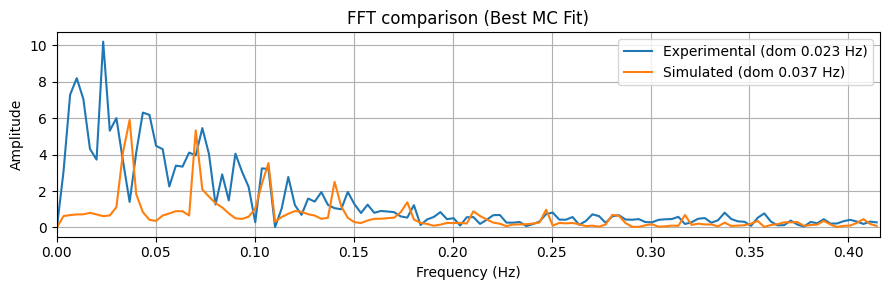

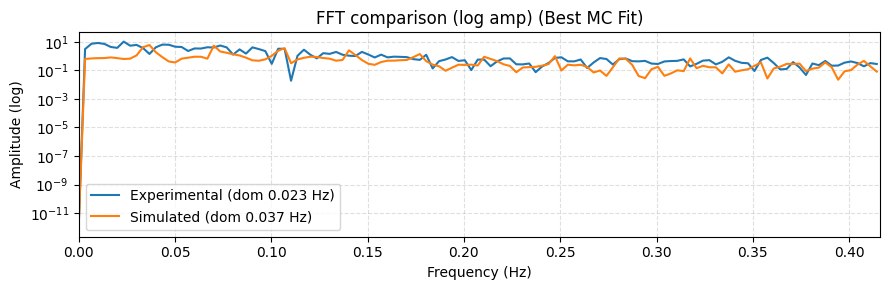

In [ ]:
# ==========================================
# 6. Frequency Analysis (FFT Visualization)
# ==========================================
# Visualizing the frequency difference using FFT

# Function to calculate and plot FFT
def safe_fft_and_plot(exp_signal, sim_signal, t_exp, title_suffix=""):
    exp_signal = np.asarray(exp_signal, dtype=float)
    sim_signal = np.asarray(sim_signal, dtype=float)
    t_exp = np.asarray(t_exp, dtype=float)

    if np.isnan(exp_signal).any():
        print("WARNING: experimental signal contains NaNs. Filling via interp.")
        nans = np.isnan(exp_signal); xp = np.flatnonzero(~nans)
        exp_signal[nans] = np.interp(np.flatnonzero(nans), xp, exp_signal[~nans])
    if np.isnan(sim_signal).any():
        print("WARNING: simulated signal contains NaNs. Filling via interp.")
        nans = np.isnan(sim_signal); xp = np.flatnonzero(~nans)
        sim_signal[nans] = np.interp(np.flatnonzero(nans), xp, sim_signal[~nans])

    if np.allclose(exp_signal, exp_signal[0]):
        print("WARNING: experimental signal is constant (or nearly). FFT will be trivial.")
    if np.allclose(sim_signal, sim_signal[0]):
        print("WARNING: simulated signal is constant (or nearly). FFT will be trivial.")

    dt = np.median(np.diff(t_exp)) if len(t_exp) > 1 else 0.1 # Default to 0.1 if dt calculation fails
    if dt <= 0 or not np.isfinite(dt):
        print("WARNING: invalid dt derived; using default 0.1.")
        dt = 0.1

    n_e = len(exp_signal); n_s = len(sim_signal)
    n = max(n_e, n_s)
    if n_e < n:
        exp_signal = np.concatenate([exp_signal, np.full(n - n_e, exp_signal[-1])])
    if n_s < n:
        sim_signal = np.concatenate([sim_signal, np.full(n - n_s, sim_signal[-1])])

    exp_x = exp_signal - np.mean(exp_signal)
    sim_x = sim_signal - np.mean(sim_signal)

    from scipy.fft import rfft, rfftfreq # Import rfft and rfftfreq

    yf_e = np.abs(rfft(exp_x))
    yf_s = np.abs(rfft(sim_x))
    xf = rfftfreq(n, dt)

    if len(xf) == 0 or len(yf_e) == 0 or len(yf_s) == 0:
        print("ERROR: FFT returned empty arrays.")
        return

    def dom_freq_from_y(xf, yf):
        if len(yf) <= 1:
            return 0.0
        idx = np.argmax(yf[1:]) + 1
        return float(xf[idx])

    f_exp_dom = dom_freq_from_y(xf, yf_e)
    f_sim_dom = dom_freq_from_y(xf, yf_s)
    print(f"Dominant freq (experimental): {f_exp_dom:.6f} Hz")
    print(f"Dominant freq (simulated)   : {f_sim_dom:.6f} Hz")

    f_nyquist = 1.0 / (2.0 * dt)
    xlim_high = f_nyquist

    plt.figure(figsize=(9,3))
    plt.plot(xf, yf_e, label=f"Experimental (dom {f_exp_dom:.3f} Hz)")
    plt.plot(xf, yf_s, label=f"Simulated (dom {f_sim_dom:.3f} Hz)")
    plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")
    plt.title(f"FFT comparison {title_suffix}"); plt.xlim(0, xlim_high)
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,3))
    eps = 1e-12
    plt.semilogy(xf, yf_e + eps, label=f"Experimental (dom {f_exp_dom:.3f} Hz)")
    plt.semilogy(xf, yf_s + eps, label=f"Simulated (dom {f_sim_dom:.3f} Hz)")
    plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude (log)")
    plt.title(f"FFT comparison (log amp) {title_suffix}"); plt.xlim(0, xlim_high)
    plt.legend(); plt.grid(True, which='both', linestyle='--', alpha=0.4); plt.tight_layout(); plt.show()

# Run the FFT visualization
print("Debug (first 8 samples):")
print(" exp_norm:", np.round(np.asarray(exp_norm)[:8], 6))
print(" Ca_best :", np.round(np.asarray(best_sim_trace)[:8], 6))
safe_fft_and_plot(exp_norm, best_sim_trace, time_exp, title_suffix="(Best MC Fit)")


Generating Animation...
Video successfully saved to /content/optimization_video.mp4


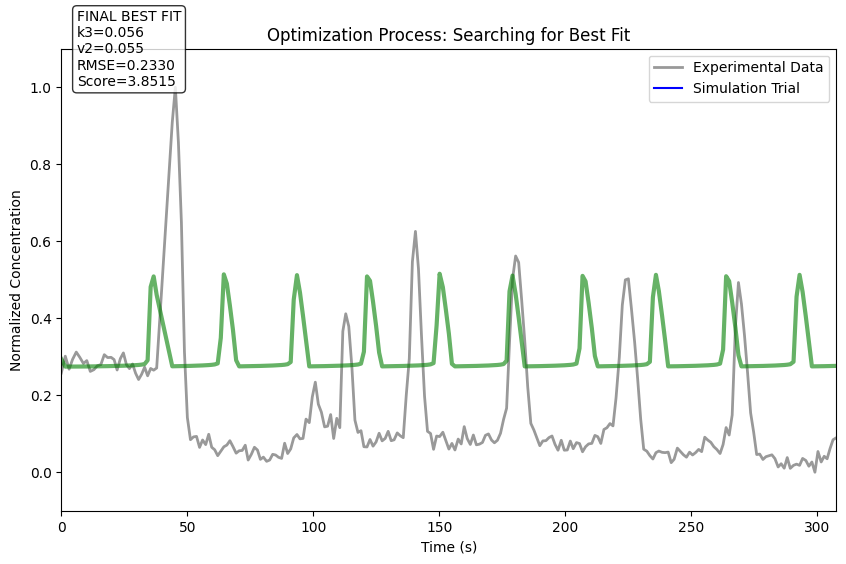

In [ ]:
# ==========================================
# 7.Animation
# ==========================================

print("Generating Animation...")

K_fig_anim, K_ax_anim = plt.subplots(figsize=(10, 6))
K_ax_anim.set_xlim(time_exp[0], time_exp[-1])
K_ax_anim.set_ylim(-0.1, 1.1)
K_ax_anim.set_title("Optimization Process: Searching for Best Fit")
K_ax_anim.set_xlabel("Time (s)")
K_ax_anim.set_ylabel("Normalized Concentration")

# Static experimental line (background)
K_line_exp, = K_ax_anim.plot(time_exp, exp_norm, 'k-', alpha=0.4, linewidth=2, label='Experimental Data')

# Dynamic simulation line
K_line_sim, = K_ax_anim.plot([], [], 'b-', linewidth=1.5, label='Simulation Trial')

# Stats Text
K_txt = K_ax_anim.text(0.02, 0.92, '', transform=K_ax_anim.transAxes,
                       bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))
K_ax_anim.legend(loc='upper right')

def init():
    K_line_sim.set_data([], [])
    K_txt.set_text('')
    return K_line_sim, K_txt

def update(frame_idx):
    # Access data from our collected frames
    data = animation_frames[frame_idx]

    y_sim = data['sim_data']
    k3 = data['k3']
    v2 = data['v2']
    rmse = data['rmse']
    score = data['score']
    frame_type = data['type']

    # Update Plot Data
    K_line_sim.set_data(time_exp, y_sim)

    # Visual Logic
    if frame_type == 'best':
        K_line_sim.set_color('green')
        K_line_sim.set_linewidth(3)
        K_line_sim.set_label("BEST FIT FOUND")
        label = f"FINAL BEST FIT\nk3={k3:.3f}\nv2={v2:.3f}\nRMSE={rmse:.4f}\nScore={score:.4f}"
    else:
        # Standard Trial
        K_line_sim.set_color('blue')
        K_line_sim.set_linewidth(1)
        K_line_sim.set_alpha(0.6)
        label = f"Iteration: {frame_idx}\nk3={k3:.3f}, v2={v2:.3f}\nRMSE={rmse:.4f}"

    K_txt.set_text(label)
    return K_line_sim, K_txt

# Create Animation
# frames is the number of items in our list
K_anim = animation.FuncAnimation(K_fig_anim, update, frames=len(animation_frames),
                                 init_func=init, blit=True, interval=50)

# Save Video
K_video_filename = '/content/optimization_video.mp4'
try:
    K_writer = animation.FFMpegWriter(fps=15)
    K_anim.save(K_video_filename, writer=K_writer)
    print(f"Video successfully saved to {K_video_filename}")
except Exception as e:
    print(f"Error saving video (FFmpeg might not be installed): {e}")
    from IPython.display import HTML
    HTML(K_anim.to_jshtml())


--- Strategy B: Systematic Grid Search (30x30) ---
Best Grid Params: {'k3': np.float64(0.0603448275862069), 'v2': np.float64(0.06724137931034482)}


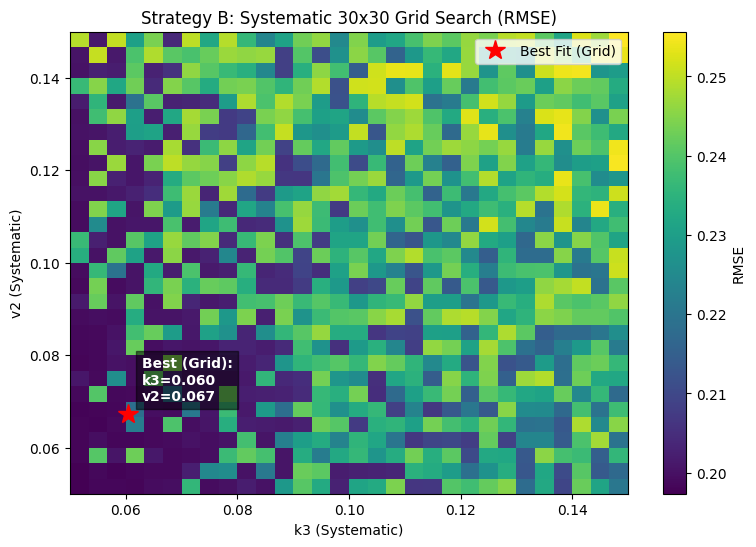

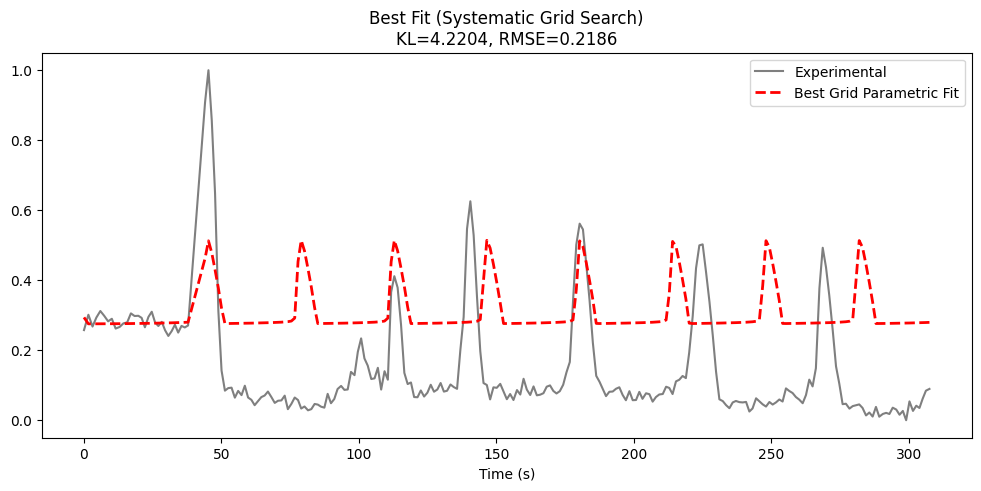

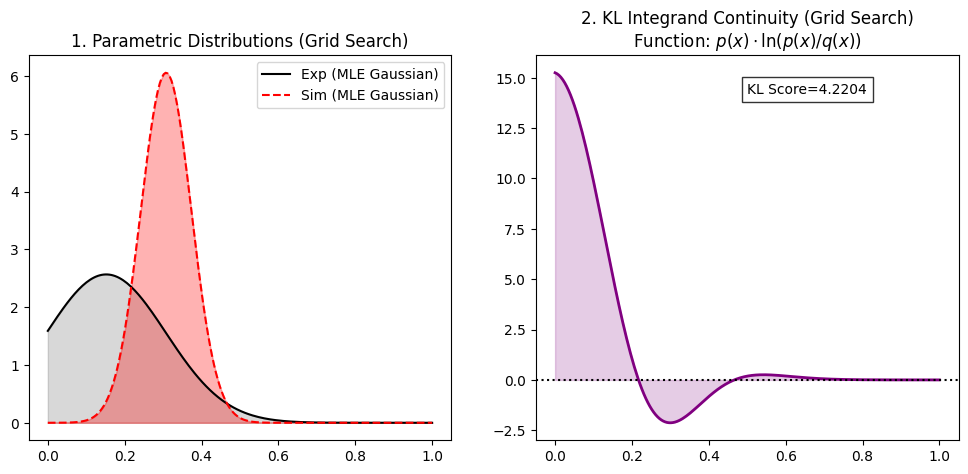

In [ ]:
# ==========================================
# BONUS : Systematic Grid Search (Hybrid)
# ==========================================
# (Kept as your original "bonus", Monte Carlo is now clearly the main objective plot)
print("\n--- Strategy B: Systematic Grid Search (30x30) ---")

k3_range = (0.05, 0.15)
v2_range = (0.05, 0.15)
d5_range = (0.05, 0.15)
a2_range = (0.1, 0.3)

N_GRID = 30
k3_grid = np.linspace(k3_range[0], k3_range[1], N_GRID)
v2_grid = np.linspace(v2_range[0], v2_range[1], N_GRID)

grid_rmse_map = np.zeros((N_GRID, N_GRID))
best_grid_score = float('inf')
best_grid_params = {}
best_grid_trace = None
best_grid_metrics = {}

np.random.seed(44) # Set seed for reproducibility of random d5 and a2

for i, k3_val in enumerate(k3_grid):
    for j, v2_val in enumerate(v2_grid):

        # Vary d5, a2 randomly AT EACH GRID POINT (Hybrid)
        d5_val = np.random.uniform(*d5_range)
        a2_val = np.random.uniform(*a2_range)

        t_sim, sim_raw, _ = simulate_lir_rinzel(k3_val, v2_val, d5_val, a2_val, t_max=time_exp[-1])

        if np.max(sim_raw) - np.min(sim_raw) < 1e-6:
             sim_interp = np.zeros_like(time_exp)
        else:
             sim_norm_raw = scaler.transform(sim_raw.reshape(-1, 1)).flatten()
             sim_interp = np.interp(time_exp, t_sim, sim_norm_raw)

        # Metrics
        peaks_exp, _ = find_peaks(exp_norm, height=0.2, distance=10)
        freq_exp = 1 / np.mean(np.diff(time_exp[peaks_exp])) if len(peaks_exp) > 1 else 0
        peaks_sim, _ = find_peaks(sim_interp, height=0.2, distance=10)
        freq_sim = 1 / np.mean(np.diff(time_exp[peaks_sim])) if len(peaks_sim) > 1 else 0
        freq_diff = abs(freq_exp - freq_sim)

        kl_val, _, _, _ = calculate_parametric_kl(exp_norm, sim_interp)
        rmse_val = np.sqrt(np.mean((exp_norm - sim_interp) ** 2))

        grid_rmse_map[i, j] = rmse_val # Store for Heatmap

        score = (freq_diff * 5.0) + kl_val
        if score < best_grid_score:
            best_grid_score = score
            best_grid_params = {'k3': k3_val, 'v2': v2_val}
            best_grid_trace = sim_interp
            best_grid_metrics = {'KL': kl_val, 'RMSE': rmse_val, 'FreqDiff': freq_diff}

print(f"Best Grid Params: {best_grid_params}")

# ==========================================
# Visualizations for Systematic Grid Search
# ==========================================

# A. Grid Search RMSE (Matrix Heatmap) - Strategy B
plt.figure(figsize=(9, 6))
plt.imshow(grid_rmse_map.T, extent=[k3_range[0], k3_range[1], v2_range[0], v2_range[1]],
           origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='RMSE')
plt.plot(best_grid_params['k3'], best_grid_params['v2'], 'r*', markersize=15, label='Best Fit (Grid)')
# Annotate Best Params
plt.annotate(f"Best (Grid):\nk3={best_grid_params['k3']:.3f}\nv2={best_grid_params['v2']:.3f}",
             (best_grid_params['k3'], best_grid_params['v2']), color='white', fontweight='bold',
             xytext=(10, 10), textcoords='offset points', bbox=dict(facecolor='black', alpha=0.5))
plt.xlabel('k3 (Systematic)')
plt.ylabel('v2 (Systematic)')
plt.title('Strategy B: Systematic 30x30 Grid Search (RMSE)')
plt.legend()
plt.show()


# B. Best Fit Time Series for Grid Search
plt.figure(figsize=(12, 5))
plt.plot(time_exp, exp_norm, 'k-', alpha=0.5, label='Experimental')
if best_grid_trace is not None:
    plt.plot(time_exp, best_grid_trace, 'r--', linewidth=2, label='Best Grid Parametric Fit')
plt.title(f"Best Fit (Systematic Grid Search)\nKL={best_grid_metrics['KL']:.4f}, RMSE={best_grid_metrics['RMSE']:.4f}")
plt.xlabel('Time (s)')
plt.legend()
plt.show()

# C. Parametric KL Continuity (Integrand Plot) for Grid Search
_, x_grid_grid, p_pdf_grid, q_pdf_grid = calculate_parametric_kl(exp_norm, best_grid_trace)
integrand_grid = p_pdf_grid * np.log(p_pdf_grid / q_pdf_grid)

fig, (ax1_grid, ax2_grid) = plt.subplots(1, 2, figsize=(12, 5))
# PDFs
ax1_grid.plot(x_grid_grid, p_pdf_grid, 'k-', label='Exp (MLE Gaussian)')
ax1_grid.plot(x_grid_grid, q_pdf_grid, 'r--', label='Sim (MLE Gaussian)')
ax1_grid.fill_between(x_grid_grid, p_pdf_grid, alpha=0.3, color='gray')
ax1_grid.fill_between(x_grid_grid, q_pdf_grid, alpha=0.3, color='red')
ax1_grid.set_title("1. Parametric Distributions (Grid Search)")
ax1_grid.legend()

# Integrand
ax2_grid.plot(x_grid_grid, integrand_grid, 'purple', linewidth=2)
ax2_grid.fill_between(x_grid_grid, integrand_grid, color='purple', alpha=0.2)
ax2_grid.axhline(0, color='k', linestyle=':')
ax2_grid.set_title("2. KL Integrand Continuity (Grid Search)\nFunction: " + r"$p(x) \cdot \ln(p(x)/q(x))$")
ax2_grid.text(0.5, 0.9, f"KL Score={best_grid_metrics['KL']:.4f}", transform=ax2_grid.transAxes,
         bbox=dict(facecolor='white', alpha=0.8))
plt.show()


COMPARING SEARCH STRATEGIES


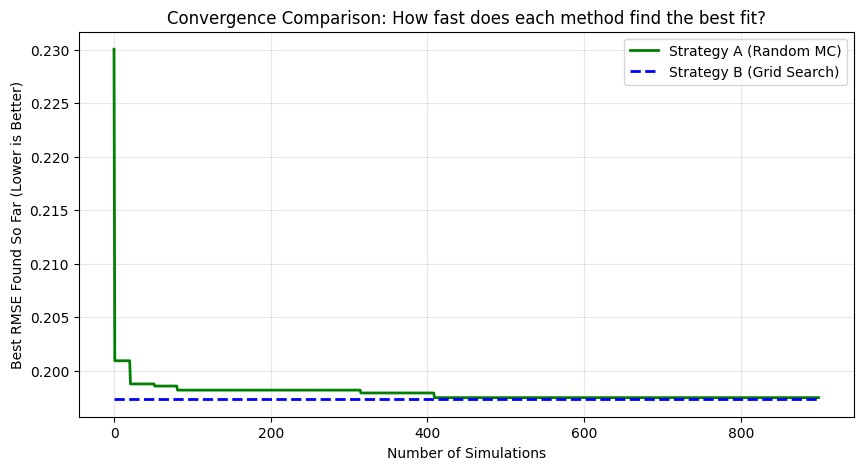

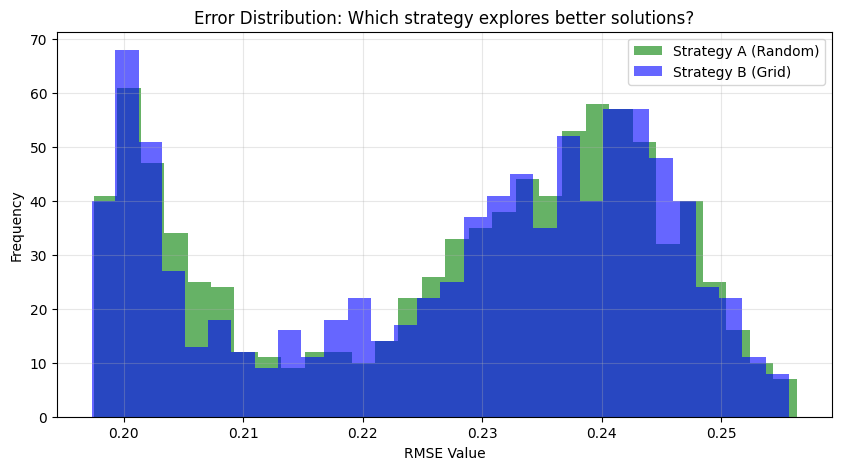

--- Final Comparison Results ---
Total Iterations: 900
Best RMSE found by Strategy A (Random): 0.19750
Best RMSE found by Strategy B (Grid):   0.19735
>> WINNER: Strategy B (Grid Search) found a better fit.


In [ ]:
# ==========================================
# COMPARISON: Monte Carlo vs Systematic search
# ==========================================

print("\n==========================================")
print("COMPARING SEARCH STRATEGIES")
print("==========================================")

# 1. Prepare Data for Comparison
rmse_strategy_a = np.array(results_rmse)
rmse_strategy_b = grid_rmse_map.flatten()

# 2. Calculate "Convergence" (Best score found over time)
convergence_a = np.minimum.accumulate(rmse_strategy_a)
convergence_b = np.minimum.accumulate(rmse_strategy_b)

# Limit to the shorter length to avoid errors
min_len = min(len(convergence_a), len(convergence_b))
iterations = np.arange(min_len)

# 3. VISUALIZATION 1: Convergence Plot
plt.figure(figsize=(10, 5))
plt.plot(iterations, convergence_a[:min_len], 'g-', label='Strategy A (Random MC)', linewidth=2)
plt.plot(iterations, convergence_b[:min_len], 'b--', label='Strategy B (Grid Search)', linewidth=2)
plt.title("Convergence Comparison: How fast does each method find the best fit?")
plt.xlabel("Number of Simulations")
plt.ylabel("Best RMSE Found So Far (Lower is Better)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. VISUALIZATION 2: Error Distribution Histogram
plt.figure(figsize=(10, 5))
plt.hist(rmse_strategy_a, bins=30, alpha=0.6, color='green', label='Strategy A (Random)')
plt.hist(rmse_strategy_b, bins=30, alpha=0.6, color='blue', label='Strategy B (Grid)')
plt.title("Error Distribution: Which strategy explores better solutions?")
plt.xlabel("RMSE Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Text Summary
best_a = np.min(rmse_strategy_a)
best_b = np.min(rmse_strategy_b)

print(f"--- Final Comparison Results ---")
print(f"Total Iterations: {min_len}")
print(f"Best RMSE found by Strategy A (Random): {best_a:.5f}")
print(f"Best RMSE found by Strategy B (Grid):   {best_b:.5f}")

if best_a < best_b:
    print(">> WINNER: Strategy A (Random Search) found a better fit.")
elif best_b < best_a:
    print(">> WINNER: Strategy B (Grid Search) found a better fit.")
else:
    print(">> TIE: Both strategies found the same minimum.")

In [ ]:
# ==========================================
# FINAL NUMERICAL SUMMARY (PROJECT RESULTS)
# ==========================================

from scipy.fft import rfft, rfftfreq

def _dominant_freq(sig, t):
    """Small helper for summary: dominant frequency in Hz."""
    sig = np.asarray(sig, dtype=float)
    t = np.asarray(t, dtype=float)
    if len(sig) < 3 or len(t) < 2:
        return 0.0
    dt = np.median(np.diff(t))
    if dt <= 0 or not np.isfinite(dt):
        return 0.0
    x = sig - np.mean(sig)
    yf = np.abs(rfft(x))
    xf = rfftfreq(len(x), dt)
    if len(yf) <= 1:
        return 0.0
    idx = np.argmax(yf[1:]) + 1
    return float(xf[idx])

print("\n==========================================")
print("FINAL SUMMARY OF RESULTS")
print("==========================================")

# ---- Basic data info ----
total_time = float(time_exp[-1] - time_exp[0])
n_points   = len(time_exp)
print(f"Data length           : {n_points} samples")
print(f"Total duration        : {total_time:.2f} s")
print(f"Experimental dt (med) : {np.median(np.diff(time_exp)):.4f} s")

# ---- Experimental vs best-fit frequencies ----
f_exp_summary = _dominant_freq(exp_norm, time_exp)
f_sim_summary = _dominant_freq(best_sim_trace, time_exp) if best_sim_trace is not None else np.nan
print("\nFREQUENCY CONTENT (dominant FFT component):")
print(f"  Experimental freq   : {f_exp_summary:.4f} Hz")
print(f"  Best-fit sim freq   : {f_sim_summary:.4f} Hz")
print(f"  |Δf|                 : {abs(f_exp_summary - f_sim_summary):.4f} Hz")

# ---- Monte Carlo best fit ----
print("\nMONTE CARLO BEST FIT (Strategy A):")
print(f"  Best parameters     : k3 = {best_params['k3']:.5f}, "
      f"v2 = {best_params['v2']:.5f}, "
      f"d5 = {best_params['d5']:.5f}, "
      f"a2 = {best_params['a2']:.5f}")
print(f"  RMSE (after fit)    : {best_metrics['RMSE']:.6f}")
print(f"  KL (Gaussian)       : {best_metrics['KL']:.6f}")
print(f"  |Δf| (objective term): {best_metrics['FreqDiff']:.6f}")
print(f"  Objective value     : {best_score:.6f}  (freq_diff + KL)")

# ---- Before vs after comparison ----
print("\nBEFORE vs AFTER PARAMETER ESTIMATION:")
print(f"  BEFORE  -> RMSE = {rmse_before:.6f}, KL = {kl_before:.6f}")
print(f"  AFTER   -> RMSE = {best_metrics['RMSE']:.6f}, KL = {best_metrics['KL']:.6f}")

# ---- Optional: Gamma-based KL for best fit ----
try:
    kl_gamma_best, _, _, _ = calculate_parametric_kl_gamma(exp_norm, best_sim_trace)
    print(f"\nGamma-based KL (best fit, optional check): {kl_gamma_best:.6f}")
except Exception as e:
    print("\nGamma-based KL could not be computed:", e)

# ---- Grid-search summary ----
print("\nSYSTEMATIC GRID SEARCH (Strategy B):")
print(f"  Best grid params    : k3 = {best_grid_params['k3']:.5f}, "
      f"v2 = {best_grid_params['v2']:.5f}")
print(f"  Best grid RMSE      : {best_grid_metrics['RMSE']:.6f}")
print(f"  Best grid KL        : {best_grid_metrics['KL']:.6f}")
print(f"  Best grid |Δf|      : {best_grid_metrics['FreqDiff']:.6f}")
print(f"  Grid objective (5*|Δf| + KL): {best_grid_score:.6f}")

# ---- Direct MC vs Grid RMSE comparison (re-use values you computed) ----
print("\nCOMPARISON OF STRATEGIES (based on RMSE only):")
print(f"  MC best RMSE        : {best_a:.6f}")
print(f"  Grid best RMSE      : {best_b:.6f}")
if best_a < best_b:
    print("  ==> Overall, Monte Carlo (random search) found a better fit.")
elif best_b < best_a:
    print("  ==> Overall, Systematic grid search found a better fit.")
else:
    print("  ==> Both strategies reached the same minimum RMSE.")

print("==========================================")
print("End of summary.")
print("==========================================\n")


FINAL SUMMARY OF RESULTS
Data length           : 249 samples
Total duration        : 307.47 s
Experimental dt (med) : 1.2020 s

FREQUENCY CONTENT (dominant FFT component):
  Experimental freq   : 0.0234 Hz
  Best-fit sim freq   : 0.0368 Hz
  |Δf|                 : 0.0134 Hz

MONTE CARLO BEST FIT (Strategy A):
  Best parameters     : k3 = 0.05578, v2 = 0.05500, d5 = 0.06379, a2 = 0.14200
  RMSE (after fit)    : 0.233024
  KL (Gaussian)       : 3.846850
  |Δf| (objective term): 0.004669
  Objective value     : 3.851519  (freq_diff + KL)

BEFORE vs AFTER PARAMETER ESTIMATION:
  BEFORE  -> RMSE = 0.239715, KL = 25.266442
  AFTER   -> RMSE = 0.233024, KL = 3.846850

Gamma-based KL (best fit, optional check): 10.409208

SYSTEMATIC GRID SEARCH (Strategy B):
  Best grid params    : k3 = 0.06034, v2 = 0.06724
  Best grid RMSE      : 0.218576
  Best grid KL        : 4.220354
  Best grid |Δf|      : 0.000874
  Grid objective (5*|Δf| + KL): 4.224723

COMPARISON OF STRATEGIES (based on RMSE only):